## IoT Motion Data Analysis

### Data Loading
This section loads the dataset from a PostgreSQL database using SQL queries and prepares it for analysis in Python.

In [3]:
!pip install pandas psycopg2-binary

In [26]:
import pandas as pd
import psycopg2

conn = psycopg2.connect(
    host="localhost",
    database="iot_motion_project",
    user="postgres",
    password="aybukes3040"
)

query = "SELECT * FROM motion_data"

df = pd.read_sql(query, conn)

df.head()

/var/folders/2y/lzfd244d79n16shmkd4j9jh80000gn/T/ipykernel_4630/1084582900.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,date,time,username,wrist,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
0,1,2017-06-30,13:51:15,viktor,0,0,0.2650,-0.7814,-0.0076,-0.0590,0.0325,-2.9296
1,2,2017-06-30,13:51:16,viktor,0,0,0.6722,-1.1233,-0.2344,-0.1757,0.0208,0.1269
2,3,2017-06-30,13:51:16,viktor,0,0,0.4399,-1.4817,0.0722,-0.9105,0.1063,-2.4367
3,4,2017-06-30,13:51:16,viktor,0,0,0.3031,-0.8125,0.0888,0.1199,-0.4099,-2.9336
4,5,2017-06-30,13:51:16,viktor,0,0,0.4814,-0.9312,0.0359,0.0527,0.4379,2.4922


### Data Overview
This section provides an overview of the dataset structure, similar to initial SQL exploration, including columns, data types, and data completeness.

In [5]:
df.shape

(88588, 12)

In [6]:
df.columns

Index(['id', 'date', 'time', 'username', 'wrist', 'activity', 'acc_x', 'acc_y',
       'acc_z', 'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88588 entries, 0 to 88587
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        88588 non-null  int64  
 1   date      88588 non-null  object 
 2   time      88588 non-null  object 
 3   username  88588 non-null  object 
 4   wrist     88588 non-null  int64  
 5   activity  88588 non-null  int64  
 6   acc_x     88588 non-null  float64
 7   acc_y     88588 non-null  float64
 8   acc_z     88588 non-null  float64
 9   gyro_x    88588 non-null  float64
 10  gyro_y    88588 non-null  float64
 11  gyro_z    88588 non-null  float64
dtypes: float64(6), int64(3), object(3)
memory usage: 8.1+ MB


In [8]:
!pip install matplotlib

In [9]:
import matplotlib.pyplot as plt

### Activity Distribution Analysis
This section analyzes the distribution of walking and running activities, corresponding to the SQL GROUP BY activity query.

In [10]:
activity_counts = df['activity'].value_counts()

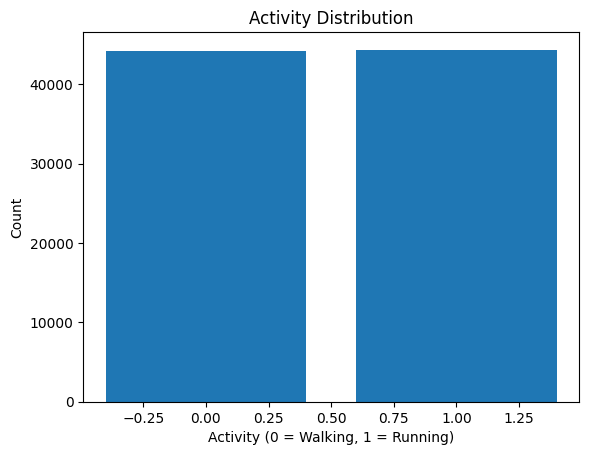

In [17]:
plt.bar(activity_counts.index, activity_counts.values)

plt.title("Activity Distribution")
plt.xlabel("Activity (0 = Walking, 1 = Running)")
plt.ylabel("Count")

plt.savefig("Desktop/iot_motion/iot_motion_images/activity_distribution.png")
plt.show()

### Magnitude Distribution Analysis (Feature Engineering)
This section visualizes the distribution of acceleration magnitude for each activity, supporting the insights obtained from SQL aggregation queries.

In [41]:
df['magnitude'] = (df['acc_x']**2 + df['acc_y']**2 + df['acc_z']**2)**0.5

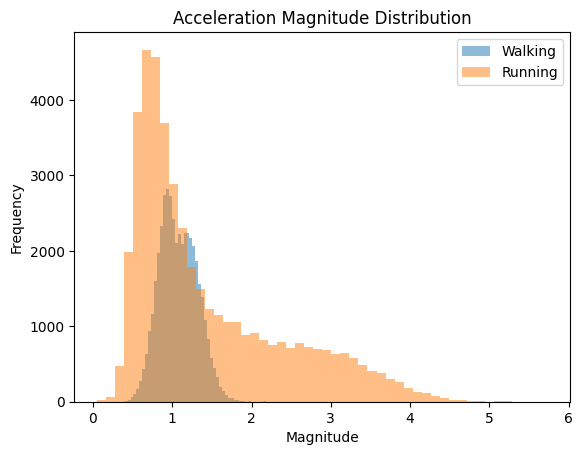

In [42]:
plt.hist(df[df['activity'] == 0]['magnitude'], bins=50, alpha=0.5, label='Walking')
plt.hist(df[df['activity'] == 1]['magnitude'], bins=50, alpha=0.5, label='Running')

plt.title("Acceleration Magnitude Distribution")
plt.xlabel("Magnitude")
plt.ylabel("Frequency")
plt.legend()


plt.savefig("iot_motion_images/iot_magnitude_distribution.png")

plt.show()

In [43]:
df.groupby('activity')['magnitude'].agg(['min', 'max'])

,min,max
activity,,
0,0.325199,2.182478
1,0.050465,5.737757


In [44]:
!pip install seaborn

In [ ]:
import os
os.listdir()

## Correlation Analysis

This section analyzes the relationships between accelerometer, gyroscope, and magnitude features to identify which variables may be most useful for activity classification.

In [18]:
corr = df.corr(numeric_only=True)
corr

,id,wrist,activity,acc_x,acc_y,acc_z,gyro_x,gyro_y,gyro_z
id,1.000000,-0.674581,0.111357,0.404612,-0.045150,-0.238204,0.017399,0.056239,-0.005804
wrist,-0.674581,1.000000,-0.113404,-0.609579,0.087091,0.323680,-0.022092,-0.068403,0.008796
activity,0.111357,-0.113404,1.000000,-0.017747,0.639520,-0.192435,0.040856,0.012055,-0.008106
acc_x,0.404612,-0.609579,-0.017747,1.000000,-0.265169,-0.552374,-0.021705,-0.004091,-0.060849
acc_y,-0.045150,0.087091,0.639520,-0.265169,1.000000,0.106220,0.010549,0.072170,-0.022994
acc_z,-0.238204,0.323680,-0.192435,-0.552374,0.106220,1.000000,0.035296,-0.021004,0.049621
gyro_x,0.017399,-0.022092,0.040856,-0.021705,0.010549,0.035296,1.000000,0.094011,0.317769
gyro_y,0.056239,-0.068403,0.012055,-0.004091,0.072170,-0.021004,0.094011,1.000000,0.287244
gyro_z,-0.005804,0.008796,-0.008106,-0.060849,-0.022994,0.049621,0.317769,0.287244,1.000000


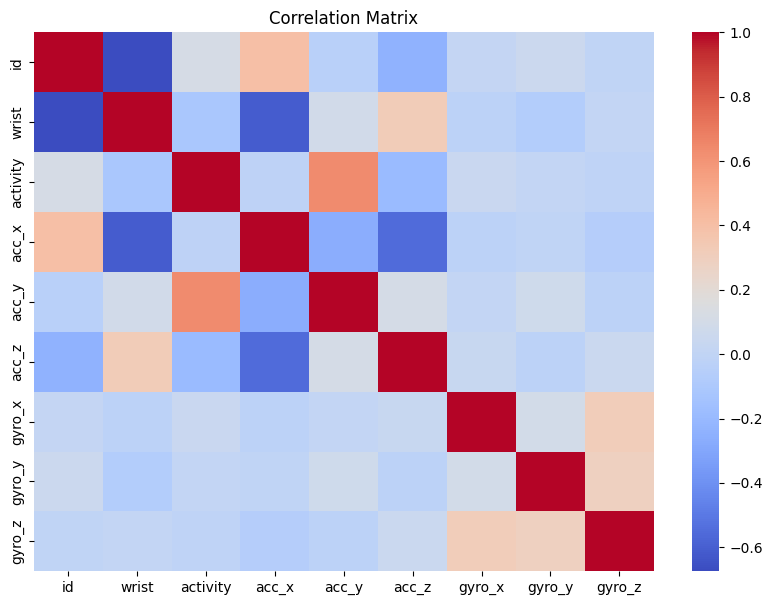

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.savefig("Desktop/iot_motion/iot_motion_images/correlation.png")
plt.show()

## Magnitude Comparison by Activity

This boxplot compares acceleration magnitude between walking and running activities to visualize differences in motion intensity and variability.

In [21]:
df.columns

Index(['id', 'date', 'time', 'username', 'wrist', 'activity', 'acc_x', 'acc_y',
       'acc_z', 'gyro_x', 'gyro_y', 'gyro_z'],
      dtype='object')

In [22]:
df['magnitude'] = (
    (df['acc_x']**2 +
     df['acc_y']**2 +
     df['acc_z']**2) ** 0.5
)

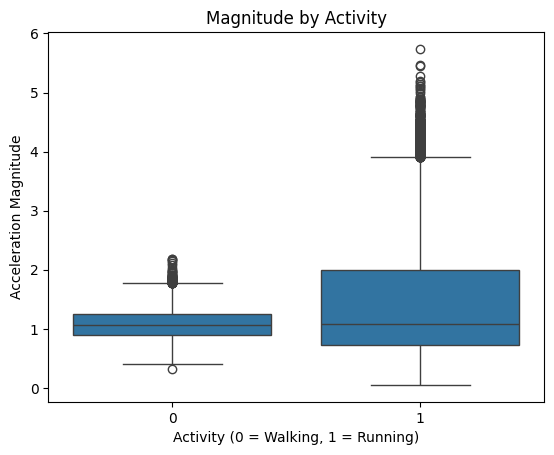

In [23]:
sns.boxplot(x='activity', y='magnitude', data=df)

plt.title("Magnitude by Activity")
plt.xlabel("Activity (0 = Walking, 1 = Running)")
plt.ylabel("Acceleration Magnitude")

plt.savefig("Desktop/iot_motion/iot_motion_images/magnitude_boxplot.png")
plt.show()

## Key EDA Insights

- `acc_y` shows the strongest relationship with activity classification, indicating it may be one of the most important features for distinguishing walking and running.

- Running activity (activity = 1) has a wider and higher acceleration magnitude distribution compared to walking, suggesting greater motion intensity and variability.

- Acceleration magnitude remains a strong engineered feature for activity classification and is expected to be important in machine learning models.